# 🎛️ Ajuste de hiperparámetros y umbral — Student Depression

Este notebook parte del baseline de `02_modeling.ipynb` y busca **mejorar el modelo** por dos vías:

1. **Ajuste de hiperparámetros** con búsqueda en malla / aleatoria (`GridSearchCV` / `RandomizedSearchCV`), optimizando **F1**.
2. **Ajuste del umbral de decisión** para **maximizar el recall** de la clase positiva sin destrozar la precisión, guiándonos por la **curva precision-recall**.

> ⚠️ **Nota ética:** el objetivo es reducir los **falsos negativos** (estudiantes en riesgo que el modelo no detecta). El resultado es una herramienta de **análisis estadístico**, **no** un instrumento de diagnóstico clínico. Cualquier uso real exigiría validación profesional y supervisión humana.

## 1. Configuración

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import PrecisionRecallDisplay

from src.data.loaders import load_raw_data
from src.features.engineering import split_X_y
from src.models.train import (
    get_models,
    build_pipeline,
    evaluate,
    tune_model,
    evaluate_at_threshold,
    threshold_for_min_precision,
    best_fbeta_threshold,
)
from src.config.constants import RANDOM_STATE, TARGET, MODELS_DIR

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Setup listo ✅")

Setup listo ✅


## 2. Carga y split

Usamos exactamente el mismo `train_test_split` (misma semilla y estratificación) que en `02_modeling.ipynb`, de modo que los resultados son **comparables** con el baseline.

In [2]:
df = load_raw_data()
X, y = split_X_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Train: 22,320  |  Test: 5,581


## 3. Ajuste de hiperparámetros (optimizando F1)

Ajustamos los tres modelos base con validación cruzada estratificada de 5 folds.
Para Logistic Regression y Decision Tree usamos **GridSearchCV** (rejillas pequeñas);
para Random Forest, **RandomizedSearchCV** (el espacio es mayor y así acotamos el coste).
Las rejillas viven en `src/models/train.py` (`get_param_grids`), reutilizables y versionadas.

In [3]:
# El método de búsqueda por modelo: malla para los baratos, aleatoria para RF.
search_strategy = {
    "Logistic Regression": "grid",
    "Decision Tree": "grid",
    "Random Forest": "random",
}

searchers = {}
rows = []
for name in get_models():
    strategy = search_strategy[name]
    print(f"Ajustando {name}  (search={strategy}) ...")
    searcher = tune_model(name, X_train, y_train, search=strategy, scoring="f1", n_iter=15)
    searchers[name] = searcher
    rows.append({
        "modelo": name,
        "search": strategy,
        "f1_cv": searcher.best_score_,
        "best_params": searcher.best_params_,
    })
    print(f"  F1 (CV) = {searcher.best_score_:.4f}")

tuning_df = pd.DataFrame(rows).sort_values("f1_cv", ascending=False).reset_index(drop=True)
tuning_df[["modelo", "search", "f1_cv"]]

Ajustando Logistic Regression  (search=grid) ...


C:\student-depression-mlops\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


  F1 (CV) = 0.8731
Ajustando Decision Tree  (search=grid) ...


  F1 (CV) = 0.8585
Ajustando Random Forest  (search=random) ...


  F1 (CV) = 0.8671


,modelo,search,f1_cv
0,Logistic Regression,grid,0.873074
1,Random Forest,random,0.867073
2,Decision Tree,grid,0.858518


In [4]:
# Mejores hiperparámetros encontrados para cada modelo
for _, row in tuning_df.iterrows():
    print(f"\n{row['modelo']}  (F1 CV = {row['f1_cv']:.4f})")
    for k, v in row["best_params"].items():
        print(f"   {k} = {v}")


Logistic Regression  (F1 CV = 0.8731)
   model__C = 0.01
   model__class_weight = None
   model__penalty = l2
   model__solver = lbfgs

Random Forest  (F1 CV = 0.8671)
   model__n_estimators = 200
   model__min_samples_leaf = 1
   model__max_features = sqrt
   model__max_depth = None
   model__class_weight = None

Decision Tree  (F1 CV = 0.8585)
   model__class_weight = None
   model__criterion = entropy
   model__max_depth = 8
   model__min_samples_leaf = 1


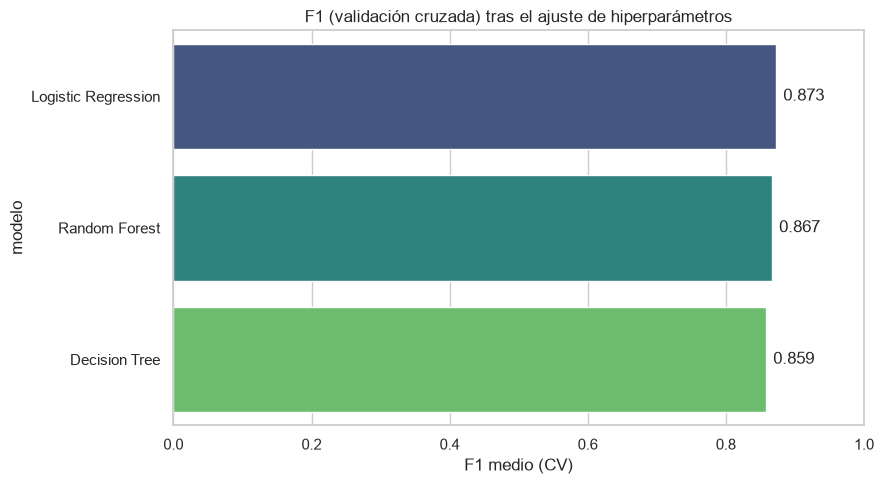

In [5]:
ax = sns.barplot(data=tuning_df, x="f1_cv", y="modelo", hue="modelo", legend=False, palette="viridis")
ax.set_title("F1 (validación cruzada) tras el ajuste de hiperparámetros")
ax.set_xlabel("F1 medio (CV)")
ax.set_xlim(0, 1)
for i, row in tuning_df.iterrows():
    ax.text(row["f1_cv"] + 0.01, i, f"{row['f1_cv']:.3f}", va="center")
plt.tight_layout()
plt.show()

## 4. Mejor modelo ajustado y evaluación en test

Tomamos el modelo con mejor F1 en validación cruzada y lo evaluamos sobre el conjunto de
prueba (umbral por defecto = 0.5), comparándolo con el **baseline** reportado en `02_modeling.ipynb`.

In [6]:
best_name = tuning_df.iloc[0]["modelo"]
best_pipe = searchers[best_name].best_estimator_
print(f"Mejor modelo ajustado: {best_name}")

metrics = evaluate(best_pipe, X_test, y_test)
print(f"\nAccuracy : {metrics['accuracy']:.4f}")
print(f"F1       : {metrics['f1']:.4f}")
print(f"ROC-AUC  : {metrics['roc_auc']:.4f}")
print(f"\nReporte de clasificación:\n{metrics['report']}")

Mejor modelo ajustado: Logistic Regression

Accuracy : 0.8438
F1       : 0.8685
ROC-AUC  : 0.9188

Reporte de clasificación:
              precision    recall  f1-score   support

           0      0.825     0.791     0.808      2313
           1      0.856     0.881     0.869      3268

    accuracy                          0.844      5581
   macro avg      0.841     0.836     0.838      5581
weighted avg      0.843     0.844     0.843      5581



In [7]:
# Comparación con el baseline (Logistic Regression sin ajustar) de 02_modeling.
baseline = {"accuracy": 0.844, "f1": 0.868, "roc_auc": 0.918, "recall_pos": 0.879}
from sklearn.metrics import recall_score
recall_pos = recall_score(y_test, metrics["y_pred"])

compare = pd.DataFrame({
    "Baseline (02)": [baseline["accuracy"], baseline["f1"], baseline["roc_auc"], baseline["recall_pos"]],
    "Ajustado (03)": [metrics["accuracy"], metrics["f1"], metrics["roc_auc"], recall_pos],
}, index=["Accuracy", "F1", "ROC-AUC", "Recall (clase 1)"]).round(4)
compare["Δ"] = (compare["Ajustado (03)"] - compare["Baseline (02)"]).round(4)
compare

,Baseline (02),Ajustado (03),Δ
Accuracy,0.844,0.8438,-0.0002
F1,0.868,0.8685,0.0005
ROC-AUC,0.918,0.9188,0.0008
Recall (clase 1),0.879,0.8813,0.0023


## 5. Ajuste del umbral de decisión (precision-recall)

En un contexto de salud mental, un **falso negativo** (no detectar a un estudiante en riesgo)
es más costoso que un **falso positivo**. El umbral por defecto de 0.5 no tiene por qué ser el
óptimo para ese objetivo. Analizamos la **curva precision-recall** y proponemos dos umbrales
alternativos:

- **Umbral con precisión mínima garantizada:** el que **maximiza el recall** manteniendo la
  precisión ≥ 0.80 (evitamos disparar los falsos positivos).
- **Umbral óptimo por F2:** F-beta con β=2 pondera el recall el doble que la precisión.

In [8]:
# Probabilidades de la clase positiva en test
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# Umbrales candidatos
thr_default = 0.5
thr_min_prec = threshold_for_min_precision(y_test, y_proba, min_precision=0.80)
thr_f2 = best_fbeta_threshold(y_test, y_proba, beta=2.0)

print(f"Umbral por defecto            : {thr_default:.3f}")
print(f"Umbral (precisión >= 0.80)    : {thr_min_prec:.3f}")
print(f"Umbral (óptimo F2)            : {thr_f2:.3f}")

Umbral por defecto            : 0.500
Umbral (precisión >= 0.80)    : 0.330
Umbral (óptimo F2)            : 0.184


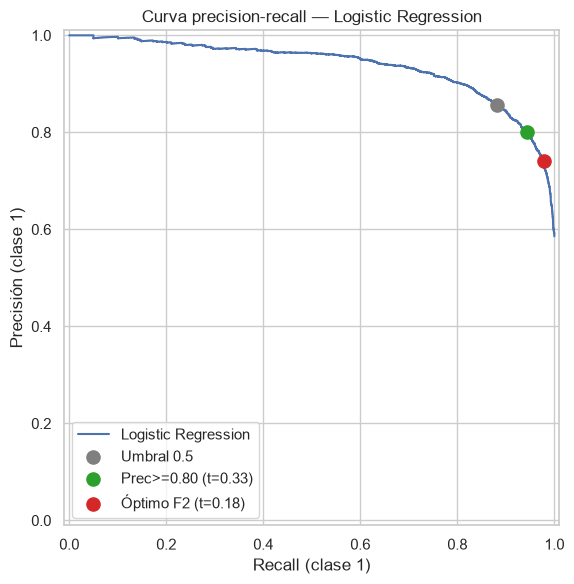

In [9]:
# Curva precision-recall con los umbrales marcados
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(9, 6))
PrecisionRecallDisplay(precision=prec, recall=rec).plot(ax=ax, name=best_name)

# Marcamos cada umbral candidato sobre la curva
for t, label, color in [
    (thr_default, "Umbral 0.5", "tab:gray"),
    (thr_min_prec, f"Prec>=0.80 (t={thr_min_prec:.2f})", "tab:green"),
    (thr_f2, f"Óptimo F2 (t={thr_f2:.2f})", "tab:red"),
]:
    m = evaluate_at_threshold(y_test, y_proba, t)
    ax.scatter(m["recall"], m["precision"], s=90, color=color, zorder=5, label=label)

ax.set_title(f"Curva precision-recall — {best_name}")
ax.set_xlabel("Recall (clase 1)")
ax.set_ylabel("Precisión (clase 1)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [10]:
# Tabla comparativa de métricas según el umbral
thr_table = pd.DataFrame([
    {**evaluate_at_threshold(y_test, y_proba, thr_default), "estrategia": "Por defecto (0.5)"},
    {**evaluate_at_threshold(y_test, y_proba, thr_min_prec), "estrategia": "Precisión >= 0.80"},
    {**evaluate_at_threshold(y_test, y_proba, thr_f2), "estrategia": "Óptimo F2"},
])
thr_table = thr_table[["estrategia", "threshold", "accuracy", "precision", "recall", "f1"]]
thr_table.round(4)

,estrategia,threshold,accuracy,precision,recall,f1
0,Por defecto (0.5),0.5000,0.8438,0.8561,0.8813,0.8685
1,Precisión >= 0.80,0.3295,0.8289,0.8000,0.9437,0.8659
2,Óptimo F2,0.1841,0.7864,0.7406,0.9777,0.8428


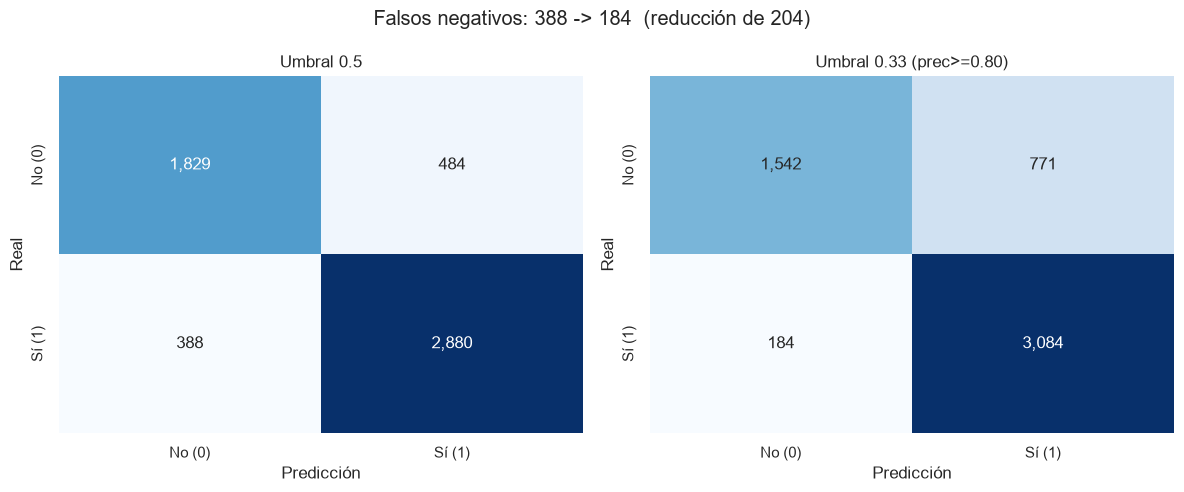

In [11]:
# Impacto en la matriz de confusión: umbral 0.5 vs umbral elegido (precisión >= 0.80)
from sklearn.metrics import confusion_matrix

chosen_thr = thr_min_prec  # umbral recomendado para este caso de uso
y_pred_default = (y_proba >= thr_default).astype(int)
y_pred_chosen = (y_proba >= chosen_thr).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in [
    (axes[0], y_pred_default, f"Umbral 0.5"),
    (axes[1], y_pred_chosen, f"Umbral {chosen_thr:.2f} (prec>=0.80)"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=["No (0)", "Sí (1)"], yticklabels=["No (0)", "Sí (1)"], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

fn_default = confusion_matrix(y_test, y_pred_default)[1, 0]
fn_chosen = confusion_matrix(y_test, y_pred_chosen)[1, 0]
plt.suptitle(f"Falsos negativos: {fn_default} -> {fn_chosen}  (reducción de {fn_default - fn_chosen})")
plt.tight_layout()
plt.show()

## 6. Guardar el modelo ajustado

Guardamos el pipeline ajustado **junto con el umbral recomendado**, para que quien lo cargue
aplique la misma regla de decisión (no el 0.5 por defecto).

In [12]:
import joblib

MODELS_DIR.mkdir(exist_ok=True)
artifact = {
    "pipeline": best_pipe,
    "model_name": best_name,
    "best_params": searchers[best_name].best_params_,
    "threshold": float(chosen_thr),
    "threshold_strategy": "recall máx. con precisión >= 0.80",
}
model_path = MODELS_DIR / "tuned_pipeline.joblib"
joblib.dump(artifact, model_path)
print(f"Modelo ajustado guardado en: {model_path}")
print(f"Umbral recomendado: {chosen_thr:.3f}")

Modelo ajustado guardado en: C:\student-depression-mlops\models\tuned_pipeline.joblib
Umbral recomendado: 0.330


## 7. Conclusiones

- El **ajuste de hiperparámetros** (F1 en validación cruzada) confirma/afina el mejor modelo
  respecto al baseline de `02_modeling.ipynb`; la tabla comparativa de la sección 4 cuantifica
  la mejora.
- El **ajuste del umbral** permite intercambiar algo de precisión por un **recall más alto**,
  reduciendo los **falsos negativos** — el error más costoso en este dominio. La curva
  precision-recall hace explícito ese equilibrio y el umbral elegido lo fija en un punto
  defendible (precisión ≥ 0.80).
- El artefacto guardado incluye el **umbral recomendado**, de modo que el criterio de decisión
  viaja con el modelo.

> ⚠️ **Recordatorio ético:** este modelo es una herramienta de **análisis estadístico** con fines
> académicos, **no** un diagnóstico clínico. Priorizar el recall busca no dejar fuera a quien
> podría necesitar apoyo, pero cualquier aplicación real requiere validación profesional,
> consentimiento informado y supervisión humana.